# ch247 — Random Variables

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. From Outcomes to Numbers

A sample space can contain anything: {H, T}, {red, green, blue}, strings. But mathematical analysis requires numbers. A **random variable** maps outcomes to numbers.

Formally: a random variable X is a function X : Ω → ℝ.

*(Functions as mappings were introduced in ch051 — What is a Function?, and ch052 — Functions as Programs.)*

Example: flip two coins. Ω = {HH, HT, TH, TT}. Define X = "number of heads":
- X(HH) = 2
- X(HT) = 1, X(TH) = 1
- X(TT) = 0

Now we can do arithmetic on outcomes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Sample space: two coin flips
Omega = list(product(['H', 'T'], repeat=2))

# Random variable X = number of heads
def X(outcome):
    return outcome.count('H')

# Induced probability distribution on X
values = {0: 0, 1: 0, 2: 0}
for omega in Omega:
    values[X(omega)] += 1 / len(Omega)  # uniform: each outcome prob 1/4

print("Sample space:", Omega)
print("\nDistribution of X = #heads:")
for x, p in sorted(values.items()):
    print(f"  P(X={x}) = {p:.4f}")

Sample space: [('H', 'H'), ('H', 'T'), ('T', 'H'), ('T', 'T')]

Distribution of X = #heads:
  P(X=0) = 0.2500
  P(X=1) = 0.5000
  P(X=2) = 0.2500


## 2. Discrete vs Continuous Random Variables

A **discrete random variable** takes values in a countable set: {0, 1, 2, ...} or any finite set.

A **continuous random variable** takes values in an interval or all of ℝ. No single point has positive probability; only intervals do.

This distinction drives which mathematical tools apply:

| Property | Discrete | Continuous |
|----------|----------|------------|
| Probability at a point | P(X = x) ≥ 0 | P(X = x) = 0 |
| Probability function | PMF (mass) | PDF (density) |
| Summing probabilities | Σ | ∫ |
| Cumulative distribution | Σ P(X ≤ x) | ∫ f(t) dt |

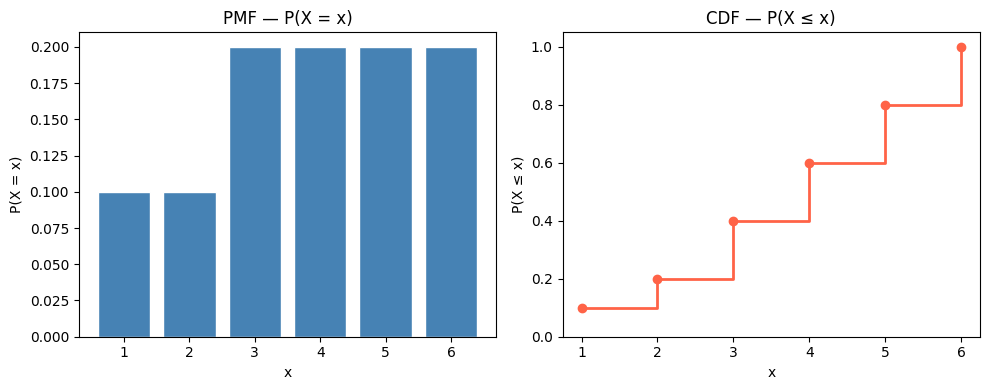

PMF: [0.1 0.1 0.2 0.2 0.2 0.2]
CDF: [0.1 0.2 0.4 0.6 0.8 1. ]


In [2]:
# Discrete RV: faces of a loaded die
faces = np.array([1, 2, 3, 4, 5, 6])
pmf = np.array([0.1, 0.1, 0.2, 0.2, 0.2, 0.2])  # P(X=k)
assert abs(pmf.sum() - 1.0) < 1e-10

# CDF: P(X <= x)
cdf = np.cumsum(pmf)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(faces, pmf, color='steelblue', edgecolor='white')
axes[0].set_title('PMF — P(X = x)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('P(X = x)')

axes[1].step(faces, cdf, where='post', color='tomato', linewidth=2)
axes[1].scatter(faces, cdf, color='tomato', zorder=5)
axes[1].set_title('CDF — P(X ≤ x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(X ≤ x)')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("PMF:", pmf)
print("CDF:", cdf)

## 3. The Probability Mass Function (PMF)

For a discrete RV X, the PMF is the function p(x) = P(X = x).

Requirements:
1. p(x) ≥ 0 for all x
2. Σₓ p(x) = 1

In [3]:
class DiscreteRV:
    """A discrete random variable defined by its PMF."""
    
    def __init__(self, values, probabilities):
        self.values = np.array(values)
        self.probs = np.array(probabilities, dtype=float)
        assert np.all(self.probs >= 0), "Probabilities must be non-negative"
        assert abs(self.probs.sum() - 1.0) < 1e-9, "Probabilities must sum to 1"
    
    def pmf(self, x):
        idx = np.where(self.values == x)[0]
        return self.probs[idx[0]] if len(idx) > 0 else 0.0
    
    def cdf(self, x):
        return self.probs[self.values <= x].sum()
    
    def sample(self, n=1, seed=None):
        rng = np.random.default_rng(seed)
        return rng.choice(self.values, size=n, p=self.probs)
    
    def expected_value(self):
        return np.sum(self.values * self.probs)
    
    def variance(self):
        mu = self.expected_value()
        return np.sum((self.values - mu)**2 * self.probs)


X_die = DiscreteRV(faces, pmf)
print(f"P(X=3) = {X_die.pmf(3):.4f}")
print(f"P(X<=3) = {X_die.cdf(3):.4f}")
print(f"E[X] = {X_die.expected_value():.4f}")
print(f"Var(X) = {X_die.variance():.4f}")
print(f"5 samples: {X_die.sample(5, seed=0)}")

P(X=3) = 0.2000
P(X<=3) = 0.4000
E[X] = 3.9000
Var(X) = 2.4900
5 samples: [5 3 1 1 6]


## 4. Functions of Random Variables

If X is a random variable and g is a function, then Y = g(X) is also a random variable.

Example: X = die roll, Y = X². What is the distribution of Y?

In [4]:
# Y = X^2 where X is uniform on {1,2,3,4,5,6}
X_uniform = DiscreteRV([1,2,3,4,5,6], [1/6]*6)

# Transform: Y = X^2
y_values = X_uniform.values ** 2
Y = DiscreteRV(y_values, X_uniform.probs)

print("Y = X² distribution:")
for v, p in zip(Y.values, Y.probs):
    print(f"  P(Y={v:2d}) = P(X={int(v**0.5)}) = {p:.4f}")

print(f"\nE[X] = {X_uniform.expected_value():.4f}")
print(f"E[X]² = {X_uniform.expected_value()**2:.4f}")
print(f"E[X²] = {Y.expected_value():.4f}")
print("\nNote: E[X²] ≠ E[X]² — Jensen's inequality for convex g.")

Y = X² distribution:
  P(Y= 1) = P(X=1) = 0.1667
  P(Y= 4) = P(X=2) = 0.1667
  P(Y= 9) = P(X=3) = 0.1667
  P(Y=16) = P(X=4) = 0.1667
  P(Y=25) = P(X=5) = 0.1667
  P(Y=36) = P(X=6) = 0.1667

E[X] = 3.5000
E[X]² = 12.2500
E[X²] = 15.1667

Note: E[X²] ≠ E[X]² — Jensen's inequality for convex g.


## 5. Multiple Random Variables and Independence

Two random variables X and Y are **independent** if knowing X gives no information about Y:
$$P(X = x, Y = y) = P(X = x) \cdot P(Y = y)$$

This is the extension of event independence *(from ch244)* to random variables.

In [5]:
# Two independent dice: joint distribution is product of marginals
from itertools import product as iproduct

marginal = np.full(6, 1/6)
joint = np.outer(marginal, marginal)  # joint[i,j] = P(X=i+1, Y=j+1)

print("Joint distribution P(X=x, Y=y) — first 3x3:")
print(joint[:3, :3])
print("\nAll values equal 1/36:", np.allclose(joint, 1/36))
print("Joint sums to 1:", abs(joint.sum() - 1.0) < 1e-10)

# Verify independence: P(X=1,Y=1) == P(X=1)*P(Y=1)
print(f"\nP(X=1,Y=1) = {joint[0,0]:.6f}")
print(f"P(X=1)*P(Y=1) = {marginal[0]*marginal[0]:.6f}")

Joint distribution P(X=x, Y=y) — first 3x3:
[[0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778]
 [0.02777778 0.02777778 0.02777778]]

All values equal 1/36: True
Joint sums to 1: True

P(X=1,Y=1) = 0.027778
P(X=1)*P(Y=1) = 0.027778


## 6. Summary

- A random variable is a function from outcomes to real numbers — it converts any experiment into a numerical one.
- Discrete RVs have PMFs; continuous RVs have PDFs. Both integrate/sum to 1.
- The CDF F(x) = P(X ≤ x) is monotone non-decreasing from 0 to 1.
- Functions of random variables are random variables: Y = g(X).
- Independence of RVs means the joint distribution factors as a product of marginals.

---

## 7. Forward References

The specific families of distributions that matter in practice — binomial, Poisson, normal — are studied in ch251–ch253. The summary statistics of a distribution (expected value and variance) are derived in ch249 and ch250. Continuous random variables require the PDF/CDF machinery formalized in ch248.